In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#imported ALL libraries in this cell even the ones used in the last cells
# to avoid import errors in the pytest tests


In [2]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/winequalityN.csv')

deciding to add the median value in the null columns

In [3]:
df.head()





,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [5]:
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\mabdu\AppData\Local\Temp\ipykernel_28612\3880857199.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\mabdu\AppData\Local\Temp\ipykernel_28612\3880857199.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [6]:
print(df.isnull().sum())


type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
print(df['type'].unique())  #checking for values in type column


['white' 'red']


In [8]:
df['type'] = df['type'].str.lower().str.strip().map({'white': 0, 'red': 1})


In [9]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,0,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,0,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


C:\Users\mabdu\AppData\Local\Temp\ipykernel_28612\1564245805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


Correlations agianst type for feature selection
type                    1.000000
volatile acidity        0.652674
chlorides               0.512636
fixed acidity           0.486930
sulphates               0.486607
density                 0.390645
pH                      0.328517
alcohol                -0.032970
quality                -0.119323
citric acid            -0.187078
residual sugar         -0.348878
free sulfur dioxide    -0.471644
total sulfur dioxide   -0.700357
Name: type, dtype: float64


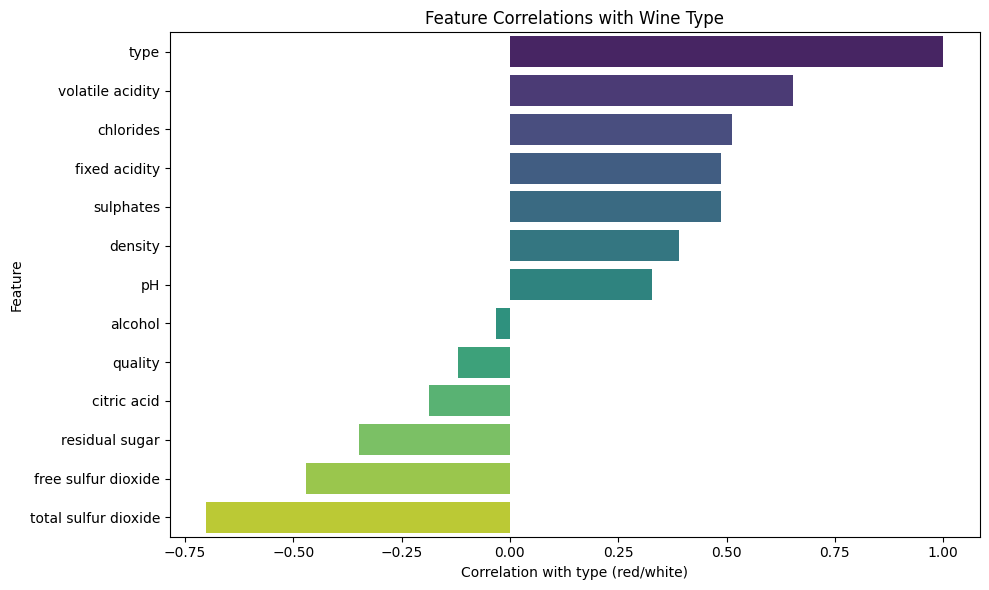

In [10]:
correlations = df.corr()['type'].sort_values(ascending=False)
print ('Correlations agianst type for feature selection')
print (correlations)

plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Feature Correlations with Wine Type')
plt.xlabel('Correlation with type (red/white)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [11]:
df.head()


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,0,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,0,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [12]:
#running model first without dropping any features

x = df.drop('type', axis =1)
y = df['type']

X_train,X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [13]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}



In [14]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9854
DecisionTree testing accuracy: 0.9838
------------------------------
KNN training accuracy: 0.9952
KNN testing accuracy: 0.9915
------------------------------
Naive-Bayes training accuracy: 0.9761
Naive-Bayes testing accuracy: 0.9723
------------------------------
KNN training accuracy: 0.9952
KNN testing accuracy: 0.9915
------------------------------
Naive-Bayes training accuracy: 0.9761
Naive-Bayes testing accuracy: 0.9723
------------------------------


In [15]:
#running model after dropping alcohol (-0.032) upon correaltion

x = df.drop(['type','alcohol'], axis =1)
y = df['type']

X_train,X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [16]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [17]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9854
DecisionTree testing accuracy: 0.9838
------------------------------
KNN training accuracy: 0.9944
KNN testing accuracy: 0.9915
------------------------------
Naive-Bayes training accuracy: 0.9763
Naive-Bayes testing accuracy: 0.9715
------------------------------
KNN training accuracy: 0.9944
KNN testing accuracy: 0.9915
------------------------------
Naive-Bayes training accuracy: 0.9763
Naive-Bayes testing accuracy: 0.9715
------------------------------


minor increase in KNN testing without alcohol


In [18]:
#running lasso and random forest classifier model for feature selection

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:

model = RandomForestClassifier(random_state =42)
model.fit(X_train_scaled,y_train)
importances = model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the most important features
rf_top_features = feature_importance_df['Feature'].head(10).tolist()
print("Top features selected by Random Forest:", rf_top_features)

Top features selected by Random Forest: ['total sulfur dioxide', 'chlorides', 'volatile acidity', 'density', 'sulphates', 'free sulfur dioxide', 'residual sugar', 'fixed acidity', 'pH', 'citric acid']


In [21]:

x = df.drop(['type'], axis =1)
y= df['type']
lasso = LassoCV().fit(x,y)



lasso_coefs = lasso.coef_
lasso_features_df = pd.DataFrame({
    'Feature': x.columns,
    'Lasso_Coefficient': lasso_coefs
}).sort_values(by='Lasso_Coefficient', key=abs, ascending=False)

print("Lasso Feature Coefficients:")
print(lasso_features_df)

# Select features with non-zero coefficients
lasso_top_features = lasso_features_df[lasso_features_df['Lasso_Coefficient'] != 0]['Feature'].tolist()
print("Top features selected by Lasso:", lasso_top_features)

Lasso Feature Coefficients:
                 Feature  Lasso_Coefficient
1       volatile acidity           0.273960
0          fixed acidity           0.073312
10               alcohol          -0.056383
3         residual sugar          -0.005579
6   total sulfur dioxide          -0.005114
5    free sulfur dioxide           0.002572
2            citric acid          -0.000000
4              chlorides           0.000000
7                density           0.000000
8                     pH           0.000000
9              sulphates           0.000000
11               quality          -0.000000
Top features selected by Lasso: ['volatile acidity', 'fixed acidity', 'alcohol', 'residual sugar', 'total sulfur dioxide', 'free sulfur dioxide']


In [22]:
#Select the top 10 features by absolute coefficient value from Lasso
lasso_top10_features = lasso_features_df.head(10)['Feature'].tolist()
print("Top 10 features selected by Lasso (by absolute coefficient value):", lasso_top10_features)

Top 10 features selected by Lasso (by absolute coefficient value): ['volatile acidity', 'fixed acidity', 'alcohol', 'residual sugar', 'total sulfur dioxide', 'free sulfur dioxide', 'citric acid', 'chlorides', 'density', 'pH']


In [23]:
selected_features = list(set(rf_top_features) & set(lasso_top_features))
print("Final selected features (intersection):", selected_features)

# Filter X with selected features
x_selected = x[selected_features]

Final selected features (intersection): ['free sulfur dioxide', 'fixed acidity', 'volatile acidity', 'total sulfur dioxide', 'residual sugar']


In [24]:
x_selected = x[selected_features]
y = df['type']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(x_selected, y, test_size=0.2, random_state=42)

In [26]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [27]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9663
DecisionTree testing accuracy: 0.9562
------------------------------
KNN training accuracy: 0.9829
KNN testing accuracy: 0.9662
------------------------------
Naive-Bayes training accuracy: 0.9415
Naive-Bayes testing accuracy: 0.9246
------------------------------
KNN training accuracy: 0.9829
KNN testing accuracy: 0.9662
------------------------------
Naive-Bayes training accuracy: 0.9415
Naive-Bayes testing accuracy: 0.9246
------------------------------



=== DecisionTree Model ===
Classification Report:
              precision    recall  f1-score   support

       White     0.9622    0.9807    0.9714       986
         Red     0.9356    0.8790    0.9064       314

    accuracy                         0.9562      1300
   macro avg     0.9489    0.9299    0.9389      1300
weighted avg     0.9558    0.9562    0.9557      1300



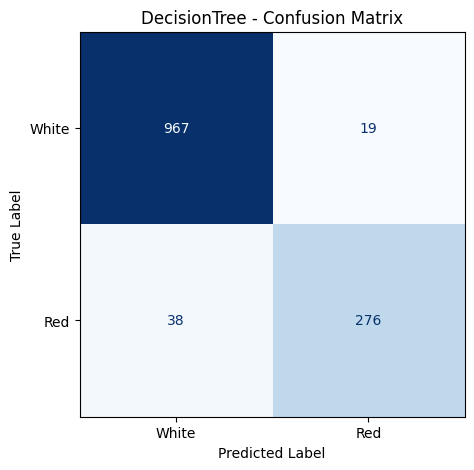


=== KNN Model ===
Classification Report:
              precision    recall  f1-score   support

       White     0.9767    0.9787    0.9777       986
         Red     0.9327    0.9268    0.9297       314

    accuracy                         0.9662      1300
   macro avg     0.9547    0.9527    0.9537      1300
weighted avg     0.9661    0.9662    0.9661      1300



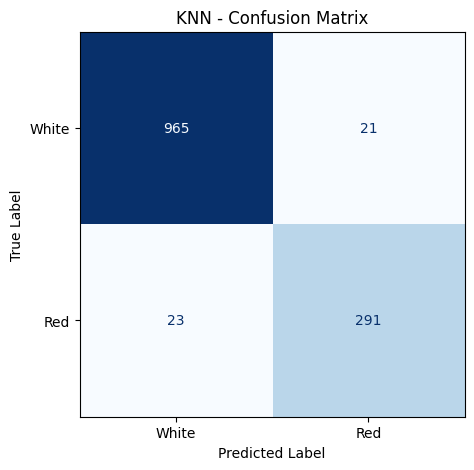


=== Naive-Bayes Model ===
Classification Report:
              precision    recall  f1-score   support

       White     0.9713    0.9280    0.9492       986
         Red     0.8017    0.9140    0.8542       314

    accuracy                         0.9246      1300
   macro avg     0.8865    0.9210    0.9017      1300
weighted avg     0.9304    0.9246    0.9262      1300

              precision    recall  f1-score   support

       White     0.9713    0.9280    0.9492       986
         Red     0.8017    0.9140    0.8542       314

    accuracy                         0.9246      1300
   macro avg     0.8865    0.9210    0.9017      1300
weighted avg     0.9304    0.9246    0.9262      1300



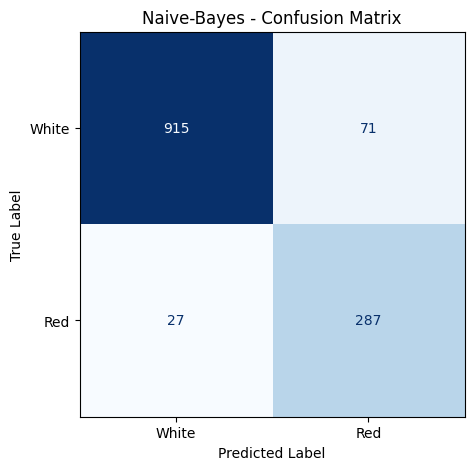

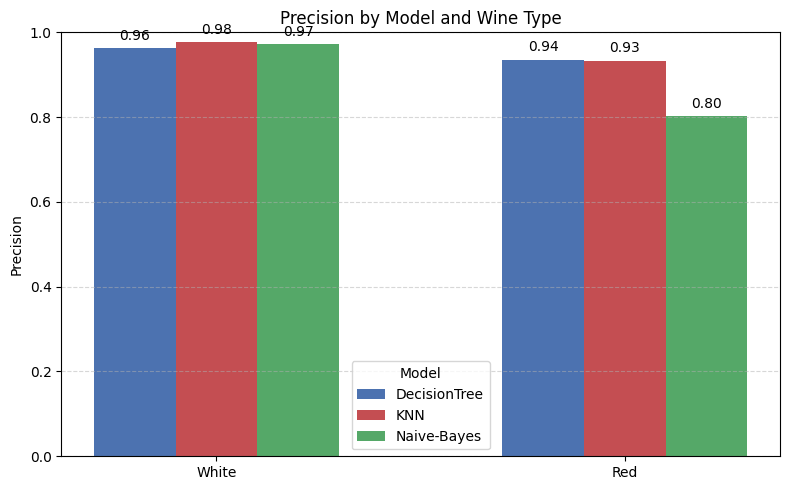

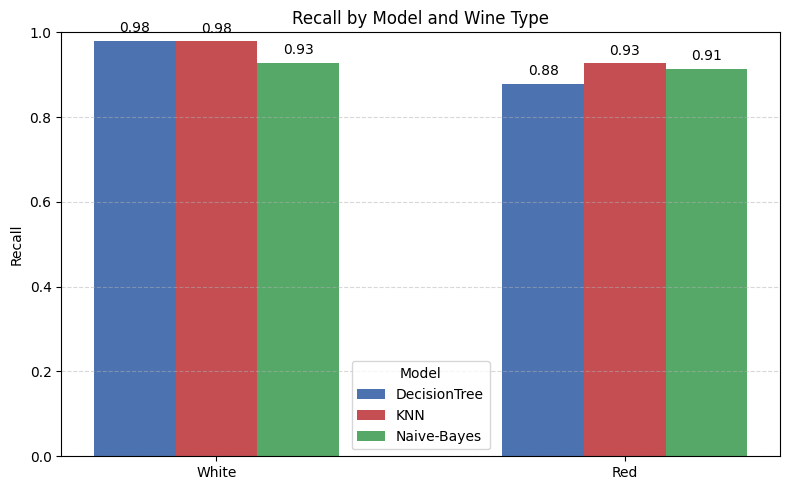

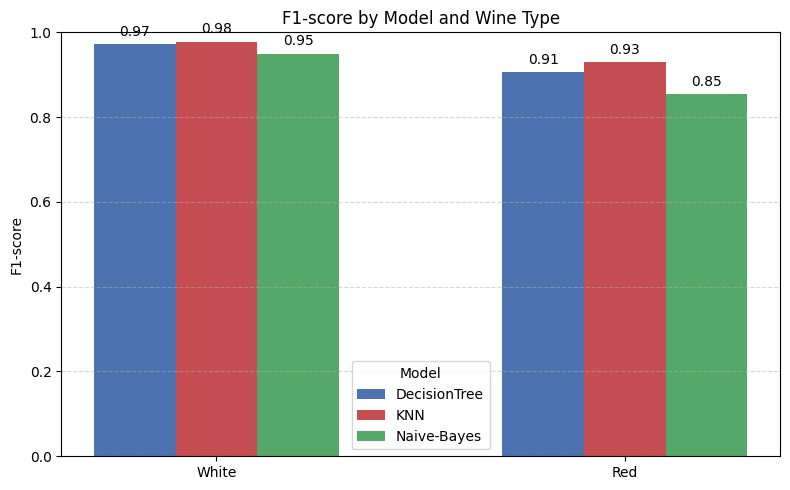

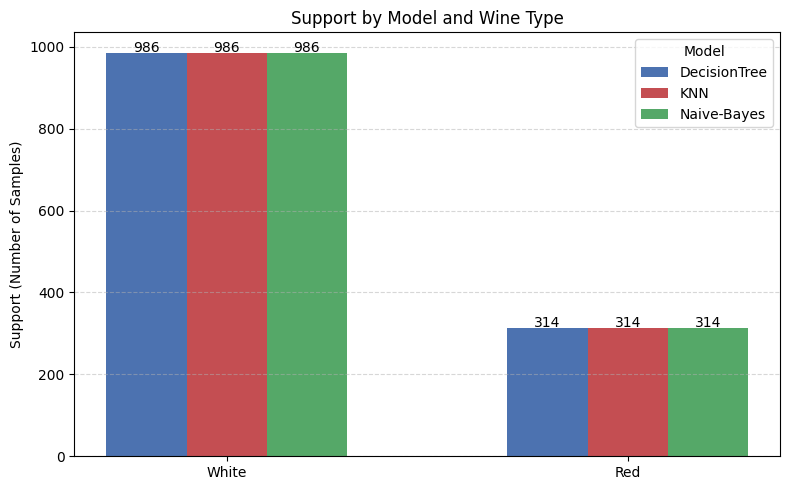

In [28]:
model_reports = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n=== {name} Model ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['White', 'Red'], digits=4))
    model_reports[name] = classification_report(y_test, y_pred, target_names=['White', 'Red'], output_dict=True)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['White', 'Red'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Individual metric bar graphs for all models
classes = ['White', 'Red']
metrics = ['precision', 'recall', 'f1-score']
colors = ['#4C72B0', '#C44E52', '#55A868']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    bar_width = 0.2
    x = np.arange(len(classes))
    for idx, (model_name, report) in enumerate(model_reports.items()):
        values = [report[cls][metric] for cls in classes]
        plt.bar(x + bar_width * idx, values, width=bar_width, label=model_name, color=colors[idx])
    plt.xticks(x + bar_width, classes)
    plt.ylim(0, 1)
    plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} by Model and Wine Type')
    plt.legend(title='Model')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for idx, (model_name, report) in enumerate(model_reports.items()):
        values = [report[cls][metric] for cls in classes]
        for i, v in enumerate(values):
            plt.text(i + bar_width * idx, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

# Bar graph for support (number of samples per class) for each model
plt.figure(figsize=(8, 5))
bar_width = 0.2
x = np.arange(len(classes))
for idx, (model_name, report) in enumerate(model_reports.items()):
    values = [report[cls]['support'] for cls in classes]
    plt.bar(x + bar_width * idx, values, width=bar_width, label=model_name, color=colors[idx])
plt.xticks(x + bar_width, classes)
plt.ylabel('Support (Number of Samples)')
plt.title('Support by Model and Wine Type')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for idx, (model_name, report) in enumerate(model_reports.items()):
    values = [report[cls]['support'] for cls in classes]
    for i, v in enumerate(values):
        plt.text(i + bar_width * idx, v + 2, f"{int(v)}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


In [29]:
# Save the trained KNN model and scaler for wine detection
import joblib

# Fit the KNN pipeline on the selected features and training data if not already done
knn_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('clf', KNeighborsClassifier())
])
knn_pipeline.fit(X_train, y_train)
joblib.dump(knn_pipeline, 'winemodel.joblib')
print("Saved KNN wine model to winemodel.joblib")

# Save the scaler separately if needed
winescaler = StandardScaler().fit(X_train)
joblib.dump(winescaler, 'winescaler.joblib')
print("Saved wine scaler to winescaler.joblib")

Saved KNN wine model to winemodel.joblib
Saved wine scaler to winescaler.joblib
